In [7]:
import numpy as np
import cv2
from pathlib import Path

# ============================================================
# CALIBRATION SETTINGS
# ============================================================
CAL_VIDEO_PATH = Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Reference\Camera_16_04_05.avi")  # Path to reference video
ROI_CAL = (1, 1, 355, 245)  # Calibration window

ELECTRODE_DIAM_MM = 3.0  # Electrode diameter (mm)
ELECTRODE_GAP_MM  = 0.6  # Electrode gap (mm) 

FPS_OVERRIDE_CAL = None  # In case of using global calibration window

def crop(frame, ROI):
    if ROI is None:
        return frame
    x0, y0, w, h = ROI
    return frame[y0:y0+h, x0:x0+w]

def get_first_frame(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open calibration video: {video_path}")
    ret, frame0 = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError("Could not read first frame from calibration video.")
    return frame0

# -----------------------------
# Click helper (OpenCV)
# -----------------------------
_clicks = []

def _on_mouse(event, x, y, flags, param):
    global _clicks
    if event == cv2.EVENT_LBUTTONDOWN:
        _clicks.append((x, y))
        print(f"Clicked: ({x}, {y})")

def click_points(img_bgr, title, n=2, scale=1.0):
    """
    Click n points on an image. Press any key to finish after clicking.
    scale: display scaling only (doesn't affect coordinates).
    Returns list of (x,y) in ORIGINAL image coordinates.
    """
    global _clicks
    _clicks = []
    img_disp = img_bgr.copy()

    if scale != 1.0:
        img_disp = cv2.resize(img_disp, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(title, _on_mouse)

    print(f"\n{title}")
    print(f"Click {n} points, then press any key...")

    while True:
        cv2.imshow(title, img_disp)
        if cv2.waitKey(1) != -1:
            break

    cv2.destroyWindow(title)

    if len(_clicks) < n:
        raise RuntimeError(f"Expected {n} clicks, got {len(_clicks)}")

    pts = [(int(x/scale), int(y/scale)) for (x, y) in _clicks[:n]]
    return pts

# ============================================================
# RUN CALIBRATION
# ============================================================
frame0 = get_first_frame(CAL_VIDEO_PATH)
frame0 = crop(frame0, ROI_CAL)

DISPLAY_SCALE = 1.5

# ---- 1) Calibrate mm/px using electrode diameter ----
pts_d = click_points(frame0, "CALIBRATION: Click electrode DIAMETER (edge-to-edge)", n=2, scale=DISPLAY_SCALE)
(x1, y1), (x2, y2) = pts_d
diam_px = float(np.hypot(x2 - x1, y2 - y1))
mm_per_px = ELECTRODE_DIAM_MM / diam_px

print("\n--- Diameter calibration ---")
print(f"Electrode diameter: {ELECTRODE_DIAM_MM:.4f} mm")
print(f"Measured diameter:  {diam_px:.2f} px")
print(f"mm_per_px:          {mm_per_px:.8f} mm/px")

# ---- 2) Sanity check + keep gap clicks for later x-centering ----
pts_g = click_points(frame0, "SANITY CHECK: Click electrode GAP (tip-to-tip)", n=2, scale=DISPLAY_SCALE)
(g1x, g1y), (g2x, g2y) = pts_g
gap_px = float(np.hypot(g2x - g1x, g2y - g1y))
gap_mm_measured = gap_px * mm_per_px

print("\n--- Gap sanity check ---")
print(f"Known gap:          {ELECTRODE_GAP_MM:.4f} mm")
print(f"Measured gap:       {gap_px:.2f} px -> {gap_mm_measured:.4f} mm")
print(f"Percent error:      {100*(gap_mm_measured - ELECTRODE_GAP_MM)/ELECTRODE_GAP_MM:+.2f}%")

print("\n✅ Calibration done. Variables now available:")
print("  mm_per_px")
print("  pts_g  (gap clicks)")



CALIBRATION: Click electrode DIAMETER (edge-to-edge)
Click 2 points, then press any key...
Clicked: (373, 11)
Clicked: (371, 195)

--- Diameter calibration ---
Electrode diameter: 3.0000 mm
Measured diameter:  123.00 px
mm_per_px:          0.02438944 mm/px

SANITY CHECK: Click electrode GAP (tip-to-tip)
Click 2 points, then press any key...
Clicked: (265, 88)
Clicked: (301, 90)

--- Gap sanity check ---
Known gap:          0.6000 mm
Measured gap:       24.08 px -> 0.5874 mm
Percent error:      -2.10%

✅ Calibration done. Variables now available:
  mm_per_px
  pts_g  (gap clicks)


C:\Users\Shabab Bin Karim\AppData\Local\Temp\ipykernel_20696\483107062.py:561: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(W, axis=0)
C:\Users\Shabab Bin Karim\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Shabab Bin Karim\AppData\Local\Temp\ipykernel_20696\483107062.py:1047: RuntimeWarning: Mean of empty slice
  seg["P_mean"] = np.nanmean(stack("P"), axis=0)


Delay 0 ns: used 21 | files=['Camera_16_21_59.avi', 'Camera_16_22_12.avi', 'Camera_16_22_21.avi', 'Camera_16_22_30.avi', 'Camera_16_22_37.avi', 'Camera_16_24_07.avi', 'Camera_16_25_16.avi', 'Camera_16_25_41.avi', 'Camera_16_25_50.avi', 'Camera_16_26_30.avi', 'Camera_16_26_40.avi', 'Camera_16_26_48.avi', 'Camera_16_49_39.avi', 'Camera_16_50_16.avi', 'Camera_16_50_52.avi', 'Camera_16_51_11.avi', 'Camera_16_51_24.avi', 'Camera_16_51_32.avi', 'Camera_16_51_41.avi', 'Camera_16_52_05.avi', 'Camera_16_52_56.avi']
Delay 18000 ns: used 5 | files=['Camera_16_27_34.avi', 'Camera_16_28_07.avi', 'Camera_16_28_17.avi', 'Camera_16_28_44.avi', 'Camera_16_29_05.avi']
Delay 36000 ns: used 8 | files=['Camera_16_30_06.avi', 'Camera_16_30_19.avi', 'Camera_16_31_44.avi', 'Camera_16_32_49.avi', 'Camera_16_33_45.avi', 'Camera_16_34_08.avi', 'Camera_16_34_20.avi', 'Camera_16_34_37.avi']
Stitched overlay saved: D:\Trial_Filament\stitched_overlay_trunk.avi

Done (stitch). Outputs saved to: D:\Trial_Filament


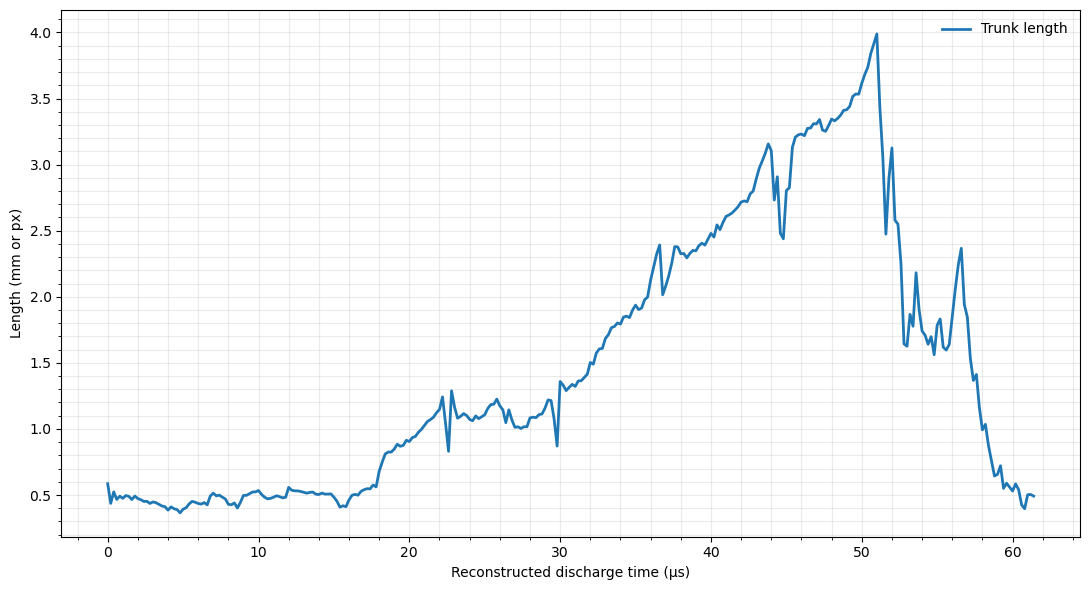

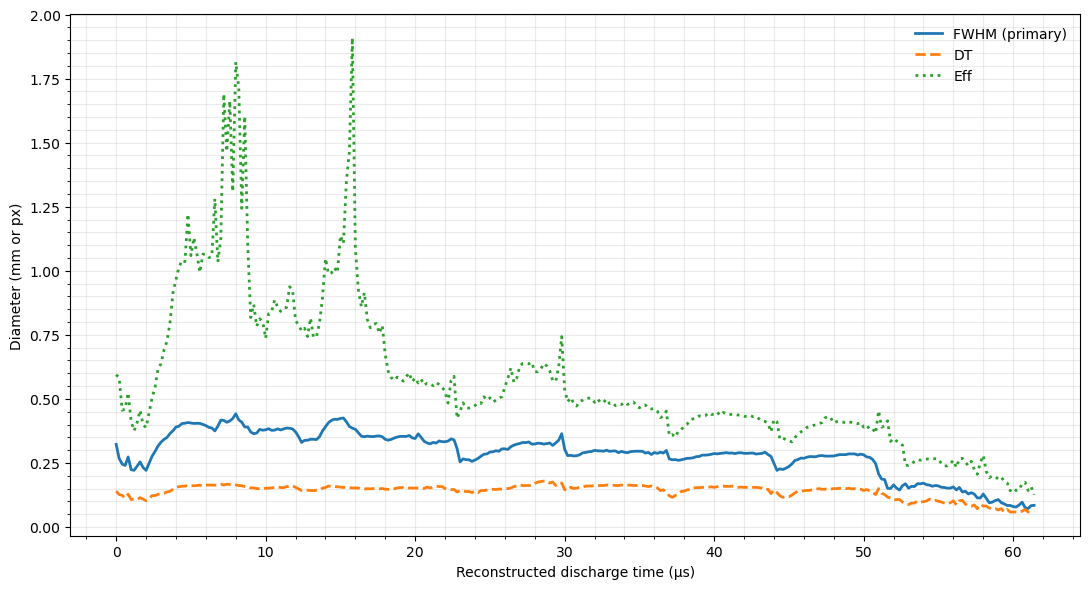

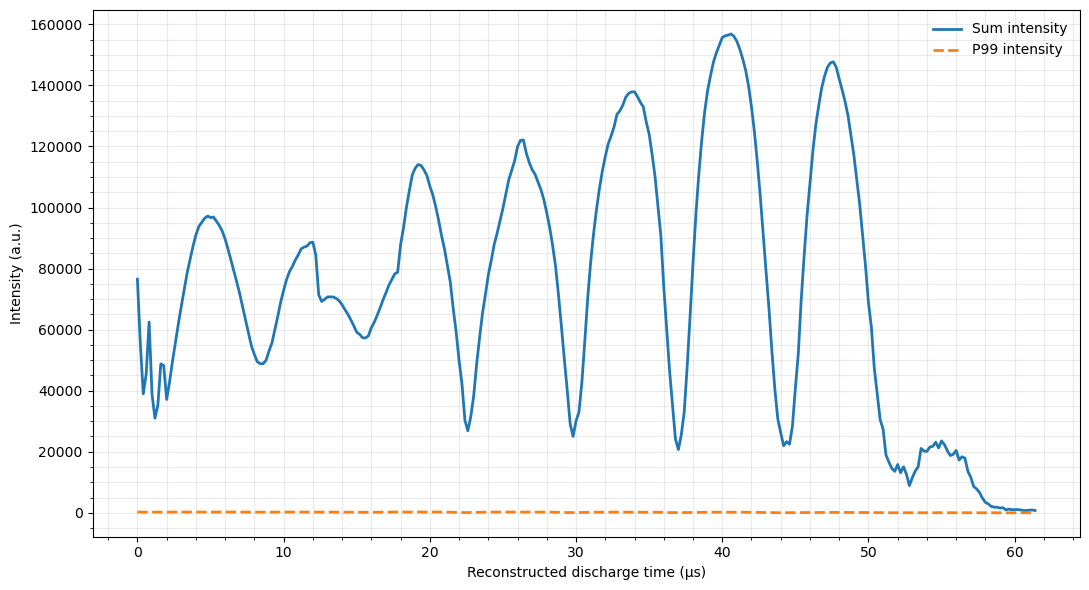

In [12]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator
try:
    from skimage.morphology import skeletonize as _sk_skeletonize
    from skimage.measure import label as _sk_label, regionprops as _sk_regionprops
    SKIMAGE_OK = True
except Exception:
    SKIMAGE_OK = False


# ============================================================
# CONFIGURATIONS
# ============================================================

OUT_DIR = Path(r"D:\Trial_Filament")   #Change in needed
OUT_DIR.mkdir(parents=True, exist_ok=True)

INDUCTANCE_UH = 560   #Change according to cases

# -----------------------------
# RUN MODE
# -----------------------------
RUN_MODE = "stitch"  # "stitch" for combining multiple videos, "single_video" for one video

# -----------------------------
# SINGLE VIDEO SETTINGS
# -----------------------------
SINGLE_VIDEO_PATH = Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\50 uH\FPS= 5 mil\Delay_0ns\Camera_17_00_49.avi")   #Change if needed
SINGLE_LABEL = "single_video"

# -----------------------------
# STITCH SETTINGS (For multiple videos)
# -----------------------------
DELAY_DIRS = {
     0:     Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\560 uH\FPS= 5 mil\Delay_0ns"),
     18000: Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\560 uH\FPS= 5 mil\Delay_18000ns"),
     36000: Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\560 uH\FPS= 5 mil\Delay_36000ns"),
}

VIDEO_MODE = "batch"  # "batch" or "single"

SINGLE_VIDEO_BY_DELAY = {
     0:     "Camera_16_26_48.avi",
     18000: "Camera_16_28_07.avi",
     36000: "Camera_16_30_19.avi",
}

EXCLUDE_STEMS = set([        
    # "bad_video_001", if videos need to be excluded form pipeline
])

# -----------------------------
# VIDEO / TIME
# -----------------------------
FPS_TRUE = 5_000_000
ROTATE_DEG = 0

ROI = (1, 1, 355, 245)  # x,y,w,h in full frame

LOCAL_START_US = 0.0
LOCAL_END_US   = 35.0

# -----------------------------
# CALIBRATION
# -----------------------------
# Pulls calibration from the calibration cell (mm_per_px)
try:
    MM_PER_PX = float(mm_per_px)   
except NameError:
    MM_PER_PX = None

REQUIRE_MM_PER_PX = True

# -----------------------------
# PRE-PROCESS / ENHANCE
# -----------------------------
USE_CLAHE = True    #  Contrast Limited Adaptive Histogram Equalization, to improve local contrast of grayscale images
CLAHE_CLIP = 2.0    #  Contrast strength. 1= Conservative, 2= Default, 3= strong
CLAHE_TILE = (8, 8) #   8x8 grid
GAUSS_BLUR = 0      # Disabled, can be used for smoothing 

# -----------------------------
# SEGMENTATION
# -----------------------------
SEG_MODE = "otsu"  # "otsu"= automatically determines the best brightness threshold,  "adaptive"= calculates a different threshold for each region of the image | "fixed"
#otsu works best for this
FIXED_THR = 40   #  If "fixed" is used
MORPH_OPEN_K = 3     #   Cleanup crew for noise
MORPH_CLOSE_K = 3

MIN_COMPONENT_AREA_PX = 50    #  Distinguish between filament and outside artifacts, like reflections

# -----------------------------
# INTENSITY METRICS SOURCE
# -----------------------------
INTENSITY_SOURCE = "enh"  # "enh"= contrast-enhanced image (after CLAHE) or "gray"= original grayscale image
INT_P99 = 99.0   #  Excludes top 1% of bright frames

# -----------------------------
# DIAMETER METRICS
# -----------------------------
DT_RADIUS_STAT = "median"  # "median" or "mean"
DT_TRIM_PCTS = (10.0, 90.0)  # trim radii, get rif=d of extreme outliers
USE_EFF_DIAM = True

# -----------------------------
# FWHM DIAMETER (PRIMARY)
# -----------------------------
FWHM_PROFILE_SOURCE = "enh"  
FWHM_SAMPLES_ALONG_TRUNK = 30   #  Total points of measurement
FWHM_HALF_PROFILE_LEN_PX = 20   #  Extension of cross section profile on each side of filament center
FWHM_N_SAMPLES_PROFILE = 2 * FWHM_HALF_PROFILE_LEN_PX + 1
FWHM_BASELINE_PCT = 10.0
FWHM_PEAK_PCT = 99.0
FWHM_MIN_PEAK_OVER_BASE = 5.0   #  Filtering bad readings

# -----------------------------
# STITCHING
# -----------------------------
ENABLE_SMOOTH_SPLICE = True
BLEND_HALF_WIDTH_US = 1.0
MAX_GLOBAL_POINTS = 400_000

# -----------------------------
# OUTPUT
# -----------------------------
SAVE_CSV = True
SAVE_PLOTS = True

# -----------------------------
# OVERLAY VIDEO EXPORT (NEW)
# -----------------------------
EXPORT_OVERLAY_SINGLE = True
EXPORT_OVERLAY_STITCH = True

OVERLAY_CODEC = "XVID"     
OVERLAY_EXT = ".avi"
OVERLAY_FPS_OUT = 30       # playback fps 
OVERLAY_ALPHA = 0.35       # mask blend alpha

OVERLAY_DRAW_MASK = True
OVERLAY_DRAW_SKELETON = True
OVERLAY_DRAW_TRUNK = True
OVERLAY_DRAW_FWHM_LINE = False
OVERLAY_TEXT = True

# stitched overlay crossfade around segment joins
STITCH_OVERLAY_BLEND = True
STITCH_OVERLAY_BLEND_HALF_WIDTH_US = 1.0


# ============================================================
# HELPERS
# ============================================================

def format_ticks(ax):
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which="both", alpha=0.25)

def rotate_frame(frame_bgr, angle_deg):
    if angle_deg == 0:
        return frame_bgr
    h, w = frame_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle_deg, 1.0)
    return cv2.warpAffine(frame_bgr, M, (w, h), flags=cv2.INTER_LINEAR)

def crop_roi(img, roi_xywh):
    x, y, w, h = roi_xywh
    return img[y:y+h, x:x+w]

def enhance_gray(gray_u8):
    out = gray_u8
    if GAUSS_BLUR and GAUSS_BLUR >= 3 and GAUSS_BLUR % 2 == 1:
        out = cv2.GaussianBlur(out, (GAUSS_BLUR, GAUSS_BLUR), 0)
    if USE_CLAHE:
        clahe = cv2.createCLAHE(clipLimit=float(CLAHE_CLIP), tileGridSize=tuple(CLAHE_TILE))
        out = clahe.apply(out)
    return out

def binarize(enh_u8):
    if SEG_MODE == "otsu":
        _, bw = cv2.threshold(enh_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif SEG_MODE == "adaptive":
        bw = cv2.adaptiveThreshold(
            enh_u8, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
            21, -5
        )
    elif SEG_MODE == "fixed":
        _, bw = cv2.threshold(enh_u8, int(FIXED_THR), 255, cv2.THRESH_BINARY)
    else:
        raise ValueError("SEG_MODE must be 'otsu', 'adaptive', or 'fixed'")

    if MORPH_OPEN_K and MORPH_OPEN_K >= 3:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_OPEN_K, MORPH_OPEN_K))
        bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k)
    if MORPH_CLOSE_K and MORPH_CLOSE_K >= 3:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_CLOSE_K, MORPH_CLOSE_K))
        bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, k)

    return bw

def largest_component_mask(bw_u8):
    if not SKIMAGE_OK:
        num, lab, stats, _ = cv2.connectedComponentsWithStats((bw_u8 > 0).astype(np.uint8), connectivity=8)
        if num <= 1:
            return None
        areas = stats[1:, cv2.CC_STAT_AREA]
        idx = int(np.argmax(areas)) + 1
        if areas[idx - 1] < MIN_COMPONENT_AREA_PX:
            return None
        return (lab == idx).astype(np.uint8)
    else:
        lab = _sk_label(bw_u8 > 0)
        if lab.max() < 1:
            return None
        props = [p for p in _sk_regionprops(lab) if p.area >= MIN_COMPONENT_AREA_PX]
        if not props:
            return None
        pmax = max(props, key=lambda p: p.area)
        return (lab == pmax.label).astype(np.uint8)

def skeletonize_mask(mask01):
    if SKIMAGE_OK:
        sk = _sk_skeletonize(mask01.astype(bool))
        return sk.astype(np.uint8)
    sk = (mask01.astype(np.uint8) * 255)
    if hasattr(cv2, "ximgproc") and hasattr(cv2.ximgproc, "thinning"):
        sk = cv2.ximgproc.thinning(sk)
    return (sk > 0).astype(np.uint8)


# ---- longest path (trunk) in skeleton ----
_NEI8 = [(-1,-1), (-1,0), (-1,1),
         (0,-1),          (0,1),
         (1,-1),  (1,0),  (1,1)]

def _skeleton_points(sk01):
    ys, xs = np.where(sk01 > 0)
    return list(zip(xs.tolist(), ys.tolist()))

def _neighbors_map(sk01):
    H, W = sk01.shape
    pts = _skeleton_points(sk01)
    S = set(pts)
    nbrs = {}
    for (x, y) in pts:
        n = []
        for dx, dy in _NEI8:
            xx, yy = x + dx, y + dy
            if 0 <= xx < W and 0 <= yy < H and (xx, yy) in S:
                n.append((xx, yy))
        nbrs[(x, y)] = n
    return nbrs

def _endpoints(nbrs):
    return [p for p, n in nbrs.items() if len(n) == 1]

def _bfs_farthest(nbrs, start):
    from collections import deque
    q = deque([start])
    dist = {start: 0}
    parent = {start: None}
    while q:
        u = q.popleft()
        for v in nbrs[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                parent[v] = u
                q.append(v)
    far = max(dist, key=lambda k: dist[k])
    return far, dist, parent

def longest_path_in_skeleton(sk01):
    nbrs = _neighbors_map(sk01)
    if not nbrs:
        return None
    ends = _endpoints(nbrs)
    start = ends[0] if ends else next(iter(nbrs.keys()))
    a, _, _ = _bfs_farthest(nbrs, start)
    b, _, parent = _bfs_farthest(nbrs, a)
    path = []
    cur = b
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path

def polyline_length_px(path_xy):
    if path_xy is None or len(path_xy) < 2:
        return np.nan
    p = np.array(path_xy, dtype=float)
    d = np.diff(p, axis=0)
    return float(np.sum(np.hypot(d[:, 0], d[:, 1])))

def sample_indices_along_path(npts, k):
    if npts <= 0:
        return []
    if k <= 1:
        return [npts // 2]
    idx = np.linspace(0, npts - 1, k).round().astype(int)
    return np.unique(idx).tolist()

def local_normal_from_path(path_xy, i):
    p = np.array(path_xy, dtype=float)
    n = len(p)
    i0 = max(0, i - 1)
    i1 = min(n - 1, i + 1)
    if i1 == i0:
        return np.array([0.0, 1.0])
    v = p[i1] - p[i0]
    nv = np.hypot(v[0], v[1])
    if nv < 1e-9:
        return np.array([0.0, 1.0])
    t = v / nv
    return np.array([-t[1], t[0]])

def sample_profile(img_u8, center_xy, normal_xy, half_len_px, n_samples):
    cx, cy = center_xy
    nrm = np.array(normal_xy, dtype=float)
    nn = np.hypot(nrm[0], nrm[1])
    if nn < 1e-9:
        return None, None
    nrm /= nn

    s = np.linspace(-half_len_px, +half_len_px, n_samples)
    xs = cx + s * nrm[0]
    ys = cy + s * nrm[1]

    H, W = img_u8.shape
    prof = []
    for x, y in zip(xs, ys):
        if x < 0 or x > (W - 1) or y < 0 or y > (H - 1):
            prof.append(np.nan)
            continue
        x0 = int(np.floor(x)); x1 = min(x0 + 1, W - 1)
        y0 = int(np.floor(y)); y1 = min(y0 + 1, H - 1)
        a = x - x0
        b = y - y0
        v00 = float(img_u8[y0, x0])
        v10 = float(img_u8[y0, x1])
        v01 = float(img_u8[y1, x0])
        v11 = float(img_u8[y1, x1])
        v0 = (1 - a) * v00 + a * v10
        v1 = (1 - a) * v01 + a * v11
        v  = (1 - b) * v0 + b * v1
        prof.append(v)
    return s, np.array(prof, dtype=float)

def fwhm_width_from_profile(s, prof):
    prof = prof.copy()
    ok = np.isfinite(prof)
    if np.sum(ok) < max(11, len(prof) // 2):
        return np.nan

    v = prof[ok]
    base = float(np.percentile(v, FWHM_BASELINE_PCT))
    peak = float(np.percentile(v, FWHM_PEAK_PCT))
    if (peak - base) < float(FWHM_MIN_PEAK_OVER_BASE):
        return np.nan
    half = base + 0.5 * (peak - base)
    y = prof - half
    mid = len(y) // 2

    left = np.nan
    for i in range(mid, 0, -1):
        if np.isfinite(y[i]) and np.isfinite(y[i-1]) and (y[i] >= 0) and (y[i-1] < 0):
            t = y[i] / (y[i] - y[i-1])
            left = s[i] - t * (s[i] - s[i-1])
            break

    right = np.nan
    for i in range(mid, len(y) - 1):
        if np.isfinite(y[i]) and np.isfinite(y[i+1]) and (y[i] >= 0) and (y[i+1] < 0):
            t = y[i] / (y[i] - y[i+1])
            right = s[i] + t * (s[i+1] - s[i])
            break

    if not (np.isfinite(left) and np.isfinite(right)):
        return np.nan
    return float(right - left)

def compute_fwhm_diameter_px(gray_u8, enh_u8, trunk_path_xy):
    if trunk_path_xy is None or len(trunk_path_xy) < 5:
        return np.nan
    src = enh_u8 if FWHM_PROFILE_SOURCE.lower().strip() == "enh" else gray_u8
    idxs = sample_indices_along_path(len(trunk_path_xy), FWHM_SAMPLES_ALONG_TRUNK)
    widths = []
    for i in idxs:
        c = trunk_path_xy[i]
        nrm = local_normal_from_path(trunk_path_xy, i)
        s, prof = sample_profile(src, c, nrm, FWHM_HALF_PROFILE_LEN_PX, FWHM_N_SAMPLES_PROFILE)
        if s is None:
            continue
        w = fwhm_width_from_profile(s, prof)
        if np.isfinite(w) and w > 0:
            widths.append(w)
    return float(np.median(widths)) if widths else np.nan

def compute_dt_diameter_px(mask01):
    m = (mask01 > 0).astype(np.uint8) * 255
    dt = cv2.distanceTransform(m, distanceType=cv2.DIST_L2, maskSize=5)
    r = dt[m > 0].astype(float)
    if r.size < 10:
        return np.nan
    lo, hi = np.percentile(r, [DT_TRIM_PCTS[0], DT_TRIM_PCTS[1]])
    r = r[(r >= lo) & (r <= hi)]
    if r.size < 10:
        return np.nan
    rad = float(np.mean(r)) if DT_RADIUS_STAT == "mean" else float(np.median(r))
    return float(2.0 * rad)

def compute_eff_diameter_px(area_px2, length_px):
    if not USE_EFF_DIAM:
        return np.nan
    if not (np.isfinite(area_px2) and np.isfinite(length_px)) or (length_px <= 0) or (area_px2 <= 0):
        return np.nan
    return float(4.0 * area_px2 / (np.pi * length_px))

def intensity_metrics(gray_u8, enh_u8, mask01):
    src = enh_u8 if INTENSITY_SOURCE.lower().strip() == "enh" else gray_u8
    vals = src[mask01 > 0].astype(float)
    if vals.size < 10:
        return np.nan, np.nan, np.nan
    return float(np.sum(vals)), float(np.mean(vals)), float(np.percentile(vals, INT_P99))

def to_units(val_px, power=1):
    if MM_PER_PX is None:
        return val_px, "px" if power == 1 else "px2"
    if power == 1:
        return val_px * MM_PER_PX, "mm"
    return val_px * (MM_PER_PX ** 2), "mm2"


# ============================================================
# Compute metrics for ONE video
# ============================================================

def compute_filament_trace(video_path: Path):
    if REQUIRE_MM_PER_PX and (MM_PER_PX is None):
        raise ValueError("MM_PER_PX is required but is None. Paste your calibration value.")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    dt_us = 1e6 / float(FPS_TRUE)

    rows = []
    for i in range(n_frames):
        ok, frame = cap.read()
        if not ok:
            break

        frame = rotate_frame(frame, ROTATE_DEG)
        roi_bgr = crop_roi(frame, ROI)
        gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
        enh = enhance_gray(gray)

        bw = binarize(enh)
        comp = largest_component_mask(bw)

        present = 0
        trunk_path = None

        length_px = np.nan
        area_px2 = np.nan
        dt_diam_px = np.nan
        eff_diam_px = np.nan
        fwhm_diam_px = np.nan

        sumI = np.nan
        meanI = np.nan
        p99I = np.nan

        if comp is not None:
            present = 1
            area_px2 = float(np.sum(comp > 0))

            sk = skeletonize_mask(comp)
            trunk_path = longest_path_in_skeleton(sk)
            length_px = polyline_length_px(trunk_path)

            dt_diam_px = compute_dt_diameter_px(comp)
            eff_diam_px = compute_eff_diameter_px(area_px2, length_px)
            fwhm_diam_px = compute_fwhm_diameter_px(gray, enh, trunk_path)

            sumI, meanI, p99I = intensity_metrics(gray, enh, comp)

        t_us = float(i * dt_us)

        length_u, len_unit = to_units(length_px, power=1)
        area_u, area_unit = to_units(area_px2, power=2)
        dt_u, d_unit = to_units(dt_diam_px, power=1)
        eff_u, _ = to_units(eff_diam_px, power=1)
        fwhm_u, _ = to_units(fwhm_diam_px, power=1)

        rows.append({
            "frame": int(i),
            "t_us": t_us,
            "present": int(present),

            f"trunk_length_{len_unit}": length_u if np.isfinite(length_u) else np.nan,
            f"area_{area_unit}": area_u if np.isfinite(area_u) else np.nan,

            f"dt_diam_{d_unit}": dt_u if np.isfinite(dt_u) else np.nan,
            f"eff_diam_{d_unit}": eff_u if np.isfinite(eff_u) else np.nan,
            f"fwhm_diam_{d_unit}": fwhm_u if np.isfinite(fwhm_u) else np.nan,

            "sum_intensity": sumI,
            "mean_intensity": meanI,
            "p99_intensity": p99I,
        })

    cap.release()

    df = pd.DataFrame(rows)
    m = (df["t_us"] >= float(LOCAL_START_US)) & (df["t_us"] <= float(LOCAL_END_US))
    return df.loc[m].reset_index(drop=True)


# ============================================================
# STITCH HELPERS
# ============================================================

def list_videos(folder: Path):
    exts = (".avi", ".mp4", ".mov", ".mkv")
    vids = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts]
    vids.sort()
    return vids

def select_videos_for_delay(folder: Path, delay_ns: int):
    vids = list_videos(folder)
    if not vids:
        return []
    mode = VIDEO_MODE.lower().strip()
    if mode == "batch":
        return [v for v in vids if v.stem not in EXCLUDE_STEMS]
    if mode == "single":
        name = SINGLE_VIDEO_BY_DELAY.get(delay_ns, None)
        if name is None:
            return []
        vp = folder / name
        return [vp] if vp.exists() else []
    raise ValueError("VIDEO_MODE must be 'batch' or 'single'")

def resample_to_grid(t_src, y_src, t_grid):
    return np.interp(t_grid, t_src, y_src, left=np.nan, right=np.nan)

def nanmean_sd(W):
    mean = np.nanmean(W, axis=0)
    sd = np.nanstd(W, axis=0, ddof=1) if W.shape[0] > 1 else np.full(W.shape[1], np.nan)
    return mean, sd

def build_safe_global_grid(t_min, t_max, dt_us, max_points=400_000):
    if t_max <= t_min:
        return np.array([t_min], dtype=float)
    dtg = float(dt_us)
    n_est = int(np.ceil((t_max - t_min) / dtg)) + 1
    if n_est > max_points:
        dtg = (t_max - t_min) / (max_points - 1)
    t = np.arange(t_min, t_max + dtg, dtg)
    if t.size > max_points:
        t = np.linspace(t_min, t_max, max_points)
    return t

def smoothstep(x):
    x = np.clip(x, 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)


# ============================================================
# OVERLAY VIDEO EXPORT
# ============================================================

def _fourcc(codec="XVID"):
    return cv2.VideoWriter_fourcc(*codec)

def _to_bgr(gray_u8):
    return cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)

def _overlay_mask(img_bgr, mask01, alpha=0.35, color=(0, 255, 0)):
    if mask01 is None:
        return img_bgr
    m = (mask01 > 0).astype(np.uint8)
    overlay = img_bgr.copy()
    overlay[m > 0] = np.array(color, dtype=np.uint8)
    return cv2.addWeighted(overlay, alpha, img_bgr, 1 - alpha, 0)

def _draw_polyline(img_bgr, path_xy, color=(0, 0, 255), thickness=2):
    if path_xy is None or len(path_xy) < 2:
        return
    pts = np.array(path_xy, dtype=np.int32).reshape((-1, 1, 2))
    cv2.polylines(img_bgr, [pts], isClosed=False, color=color, thickness=thickness)

def _put_text_lines(img_bgr, lines, x=6, y=18, dy=18):
    yy = y
    for s in lines:
        cv2.putText(img_bgr, s, (x, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(img_bgr, s, (x, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (0, 0, 0), 1, cv2.LINE_AA)
        yy += dy

def _units_for_overlay(px_val, power=1):
    if (MM_PER_PX is None) or (not np.isfinite(px_val)):
        return px_val, ("px" if power == 1 else "px2")
    if power == 1:
        return px_val * MM_PER_PX, "mm"
    return px_val * (MM_PER_PX ** 2), "mm2"

def _frame_metrics_for_overlay(gray_u8, enh_u8):
    bw = binarize(enh_u8)
    comp = largest_component_mask(bw)

    present = 0
    mask01 = None
    sk01 = None
    trunk_path = None

    length_px = np.nan
    area_px2 = np.nan
    dt_diam_px = np.nan
    eff_diam_px = np.nan
    fwhm_diam_px = np.nan
    fwhm_line = None  # endpoints for drawing

    if comp is not None:
        present = 1
        mask01 = comp
        area_px2 = float(np.sum(comp > 0))

        sk01 = skeletonize_mask(comp)
        trunk_path = longest_path_in_skeleton(sk01)
        length_px = polyline_length_px(trunk_path)

        dt_diam_px = compute_dt_diameter_px(comp)
        eff_diam_px = compute_eff_diameter_px(area_px2, length_px)
        fwhm_diam_px = compute_fwhm_diameter_px(gray_u8, enh_u8, trunk_path)

        # representative cross-section for drawing at mid-trunk
        if OVERLAY_DRAW_FWHM_LINE and (trunk_path is not None) and (len(trunk_path) >= 5):
            mid_i = len(trunk_path) // 2
            c = np.array(trunk_path[mid_i], dtype=float)
            nrm = local_normal_from_path(trunk_path, mid_i).astype(float)
            nrm /= (np.hypot(nrm[0], nrm[1]) + 1e-12)
            half = float(FWHM_HALF_PROFILE_LEN_PX)
            p0 = c - half * nrm
            p1 = c + half * nrm
            fwhm_line = ((int(round(p0[0])), int(round(p0[1]))),
                         (int(round(p1[0])), int(round(p1[1]))))

    return (present, mask01, sk01, trunk_path,
            length_px, area_px2, dt_diam_px, eff_diam_px, fwhm_diam_px,
            fwhm_line)

def export_overlay_single(video_path: Path, out_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    ok, frame0 = cap.read()
    if not ok:
        cap.release()
        raise RuntimeError("Could not read first frame for overlay export.")
    frame0 = rotate_frame(frame0, ROTATE_DEG)
    roi0 = crop_roi(frame0, ROI)
    H, W = roi0.shape[:2]
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    writer = cv2.VideoWriter(str(out_path), _fourcc(OVERLAY_CODEC), float(OVERLAY_FPS_OUT), (W, H))
    if not writer.isOpened():
        cap.release()
        raise RuntimeError(f"Could not open VideoWriter: {out_path}")

    dt_us_true = 1e6 / float(FPS_TRUE)

    i = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        t_us = i * dt_us_true
        if (t_us < LOCAL_START_US) or (t_us > LOCAL_END_US):
            i += 1
            continue

        frame = rotate_frame(frame, ROTATE_DEG)
        roi_bgr = crop_roi(frame, ROI)
        gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
        enh = enhance_gray(gray)

        (present, mask01, sk01, trunk_path,
         length_px, area_px2, dt_diam_px, eff_diam_px, fwhm_diam_px,
         fwhm_line) = _frame_metrics_for_overlay(gray, enh)

        canvas = _to_bgr(enh)

        if OVERLAY_DRAW_MASK and (mask01 is not None):
            canvas = _overlay_mask(canvas, mask01, alpha=float(OVERLAY_ALPHA), color=(0, 255, 0))

        if OVERLAY_DRAW_SKELETON and (sk01 is not None):
            ys, xs = np.where(sk01 > 0)
            canvas[ys, xs] = (255, 0, 0)

        if OVERLAY_DRAW_TRUNK and (trunk_path is not None):
            _draw_polyline(canvas, trunk_path, color=(0, 0, 255), thickness=2)

        if OVERLAY_DRAW_FWHM_LINE and (fwhm_line is not None):
            cv2.line(canvas, fwhm_line[0], fwhm_line[1], (0, 255, 255), 1, cv2.LINE_AA)

        if OVERLAY_TEXT:
            L_u, L_unit = _units_for_overlay(length_px, power=1)
            A_u, A_unit = _units_for_overlay(area_px2, power=2)
            DT_u, D_unit = _units_for_overlay(dt_diam_px, power=1)
            EFF_u, _ = _units_for_overlay(eff_diam_px, power=1)
            FWHM_u, _ = _units_for_overlay(fwhm_diam_px, power=1)

            lines = [
                f"t = {t_us:.3f} us | present={present}",
                f"L = {L_u:.3f} {L_unit} | A = {A_u:.1f} {A_unit}",
                f"D_FWHM = {FWHM_u:.3f} {D_unit}",
                f"D_DT   = {DT_u:.3f} {D_unit} | D_eff = {EFF_u:.3f} {D_unit}",
            ]
            _put_text_lines(canvas, lines)

        writer.write(canvas)
        i += 1

    cap.release()
    writer.release()
    print("Overlay saved:", out_path)

def export_overlay_stitched(out_path: Path):
    if len(DELAY_DIRS) == 0:
        raise ValueError("DELAY_DIRS is empty. Fill it to export stitched overlay.")

    delays_sorted = sorted(DELAY_DIRS.keys())
    if 0 not in delays_sorted:
        raise ValueError("DELAY_DIRS must include 0 ns.")

    # pick first usable segment to set output size
    first_vp = None
    first_delay = None
    for d_ns in delays_sorted:
        vids = select_videos_for_delay(DELAY_DIRS[d_ns], d_ns)
        if vids:
            first_vp = vids[0]
            first_delay = d_ns
            break
    if first_vp is None:
        raise RuntimeError("No videos selected for any delay; cannot export stitched overlay.")

    cap0 = cv2.VideoCapture(str(first_vp))
    ok, fr0 = cap0.read()
    cap0.release()
    if not ok:
        raise RuntimeError("Could not read first frame from first stitched segment.")
    fr0 = rotate_frame(fr0, ROTATE_DEG)
    roi0 = crop_roi(fr0, ROI)
    H, W = roi0.shape[:2]

    writer = cv2.VideoWriter(str(out_path), _fourcc(OVERLAY_CODEC), float(OVERLAY_FPS_OUT), (W, H))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter: {out_path}")

    dt_us_true = 1e6 / float(FPS_TRUE)

    def iter_segment_frames(video_path: Path, delay_ns: int):
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            raise RuntimeError(f"Could not open: {video_path}")
        i = 0
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            t_local = i * dt_us_true
            if (t_local < LOCAL_START_US) or (t_local > LOCAL_END_US):
                i += 1
                continue

            frame = rotate_frame(frame, ROTATE_DEG)
            roi_bgr = crop_roi(frame, ROI)
            gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
            enh = enhance_gray(gray)

            (present, mask01, sk01, trunk_path,
             length_px, area_px2, dt_diam_px, eff_diam_px, fwhm_diam_px,
             fwhm_line) = _frame_metrics_for_overlay(gray, enh)

            canvas = _to_bgr(enh)

            if OVERLAY_DRAW_MASK and (mask01 is not None):
                canvas = _overlay_mask(canvas, mask01, alpha=float(OVERLAY_ALPHA), color=(0, 255, 0))
            if OVERLAY_DRAW_SKELETON and (sk01 is not None):
                ys, xs = np.where(sk01 > 0)
                canvas[ys, xs] = (255, 0, 0)
            if OVERLAY_DRAW_TRUNK and (trunk_path is not None):
                _draw_polyline(canvas, trunk_path, color=(0, 0, 255), thickness=2)
            if OVERLAY_DRAW_FWHM_LINE and (fwhm_line is not None):
                cv2.line(canvas, fwhm_line[0], fwhm_line[1], (0, 255, 255), 1, cv2.LINE_AA)

            if OVERLAY_TEXT:
                t_global = (delay_ns / 1000.0) + t_local
                L_u, L_unit = _units_for_overlay(length_px, power=1)
                A_u, A_unit = _units_for_overlay(area_px2, power=2)
                DT_u, D_unit = _units_for_overlay(dt_diam_px, power=1)
                EFF_u, _ = _units_for_overlay(eff_diam_px, power=1)
                FWHM_u, _ = _units_for_overlay(fwhm_diam_px, power=1)

                lines = [
                    f"t_global = {t_global:.3f} us | delay={delay_ns/1000.0:.3f} us | present={present}",
                    f"L = {L_u:.3f} {L_unit} | A = {A_u:.1f} {A_unit}",
                    f"D_FWHM = {FWHM_u:.3f} {D_unit}",
                    f"D_DT   = {DT_u:.3f} {D_unit} | D_eff = {EFF_u:.3f} {D_unit}",
                ]
                _put_text_lines(canvas, lines)

            yield float((delay_ns / 1000.0) + t_local), canvas
            i += 1
        cap.release()

    def blend_frames(A, B, alpha):
        return cv2.addWeighted(A, 1.0 - alpha, B, alpha, 0)

    # Build chosen video per delay (same rule as stitch analysis)
    segment_streams = []
    for d_ns in delays_sorted:
        vids = select_videos_for_delay(DELAY_DIRS[d_ns], d_ns)
        if vids:
            segment_streams.append((d_ns, vids[0]))

    if len(segment_streams) < 2:
        writer.release()
        raise RuntimeError("Need at least 2 delays/videos to export stitched overlay.")

    bw = float(STITCH_OVERLAY_BLEND_HALF_WIDTH_US)

    prev_tail = []     # list of (t_global, frame)
    for seg_i, (d_ns, vp) in enumerate(segment_streams):
        frames = list(iter_segment_frames(vp, d_ns))
        if not frames:
            continue

        if (seg_i == 0) or (not STITCH_OVERLAY_BLEND) or (bw <= 0):
            for (_, fr) in frames:
                writer.write(fr)
            # keep tail window
            t_end = frames[-1][0]
            prev_tail = [(t, fr) for (t, fr) in frames if (t >= t_end - bw)]
            continue

        # Crossfade around new segment start time t0
        t0 = frames[0][0]
        tL, tR = t0 - bw, t0 + bw

        prev_in = [(t, fr) for (t, fr) in prev_tail if (t >= tL and t <= tR)]
        next_in = [(t, fr) for (t, fr) in frames if (t >= tL and t <= tR)]
        next_after = [(t, fr) for (t, fr) in frames if (t > tR)]
        next_before = [(t, fr) for (t, fr) in frames if (t < tL)]

        # write any next frames before blend window (rare)
        for (_, fr) in next_before:
            writer.write(fr)

        if (len(prev_in) < 5) or (len(next_in) < 5):
            # not enough overlap -> hard cut
            for (_, fr) in frames:
                writer.write(fr)
        else:
            next_times = np.array([t for (t, _) in next_in], dtype=float)
            for (tp, fp) in prev_in:
                j = int(np.argmin(np.abs(next_times - tp)))
                tn, fn = next_in[j]
                a = (tp - tL) / (tR - tL)
                a = float(np.clip(a, 0.0, 1.0))
                a = float(a * a * (3.0 - 2.0 * a))  # smoothstep
                writer.write(blend_frames(fp, fn, a))
            for (_, fr) in next_after:
                writer.write(fr)

        # update tail from this segment
        t_end = frames[-1][0]
        prev_tail = [(t, fr) for (t, fr) in frames if (t >= t_end - bw)]

    writer.release()
    print("Stitched overlay saved:", out_path)


# ============================================================
# RUN: SINGLE VIDEO
# ============================================================

def run_single_video():
    if not SINGLE_VIDEO_PATH.exists():
        raise FileNotFoundError(f"SINGLE_VIDEO_PATH not found: {SINGLE_VIDEO_PATH}")

    df = compute_filament_trace(SINGLE_VIDEO_PATH)

    if SAVE_CSV:
        df.to_csv(OUT_DIR / f"single_{SINGLE_LABEL}_filament_metrics.csv", index=False)

    if SAVE_PLOTS:
        len_col = [c for c in df.columns if c.startswith("trunk_length_")][0]
        area_col = [c for c in df.columns if c.startswith("area_")][0]
        dt_col = [c for c in df.columns if c.startswith("dt_diam_")][0]
        eff_col = [c for c in df.columns if c.startswith("eff_diam_")][0]
        fwhm_col = [c for c in df.columns if c.startswith("fwhm_diam_")][0]

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(df["t_us"], df[len_col], linewidth=2, label="Trunk length")
        ax.set_xlabel("Time (µs) [start-of-video reference]")
        ax.set_ylabel(len_col.replace("_", " "))
        ax.legend(frameon=False)
        format_ticks(ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"single_{SINGLE_LABEL}_length.png", dpi=300)

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(df["t_us"], df[fwhm_col], linewidth=2, label="FWHM diameter (primary)")
        ax.plot(df["t_us"], df[dt_col], linewidth=2, linestyle="--", label="DT diameter")
        ax.plot(df["t_us"], df[eff_col], linewidth=2, linestyle=":", label="Eff diameter")
        ax.set_xlabel("Time (µs)")
        ax.set_ylabel(fwhm_col.replace("_", " "))
        ax.legend(frameon=False)
        format_ticks(ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"single_{SINGLE_LABEL}_diameters.png", dpi=300)

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(df["t_us"], df[area_col], linewidth=2, label="Area")
        ax.set_xlabel("Time (µs)")
        ax.set_ylabel(area_col.replace("_", " "))
        ax.legend(frameon=False)
        format_ticks(ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"single_{SINGLE_LABEL}_area.png", dpi=300)

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(df["t_us"], df["sum_intensity"], linewidth=2, label="Sum intensity")
        ax.plot(df["t_us"], df["p99_intensity"], linewidth=2, linestyle="--", label=f"P{INT_P99:.0f} intensity")
        ax.set_xlabel("Time (µs)")
        ax.set_ylabel("Intensity (a.u.)")
        ax.legend(frameon=False)
        format_ticks(ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"single_{SINGLE_LABEL}_intensity.png", dpi=300)

    # NEW: overlay export
    if EXPORT_OVERLAY_SINGLE:
        out_vid = OUT_DIR / f"single_{SINGLE_LABEL}_overlay_trunk{OVERLAY_EXT}"
        export_overlay_single(SINGLE_VIDEO_PATH, out_vid)

    print("\nDone (single video). Outputs saved to:", OUT_DIR)


# ============================================================
# RUN: STITCH
# ============================================================

def run_stitch():
    if len(DELAY_DIRS) == 0:
        raise ValueError("DELAY_DIRS is empty. Fill it with {delay_ns: Path(...)} to use stitch mode.")

    for d_ns, folder in DELAY_DIRS.items():
        if not folder.exists():
            raise FileNotFoundError(f"Delay {d_ns} ns folder not found: {folder}")

    delays_sorted = sorted(DELAY_DIRS.keys())
    if 0 not in delays_sorted:
        raise ValueError("DELAY_DIRS must include 0 ns.")

    dt_us = 1e6 / float(FPS_TRUE)
    t_local = np.arange(float(LOCAL_START_US), float(LOCAL_END_US) + dt_us, dt_us)

    segments = []
    rej = []

    for d_ns in delays_sorted:
        vids = select_videos_for_delay(DELAY_DIRS[d_ns], d_ns)
        if len(vids) == 0:
            print(f"WARNING: delay {d_ns} ns -> no videos selected")
            continue

        per = []
        used = []

        for vp in vids:
            if vp.stem in EXCLUDE_STEMS:
                rej.append((d_ns, vp.name, "excluded_by_list"))
                continue
            try:
                df = compute_filament_trace(vp)

                len_col = [c for c in df.columns if c.startswith("trunk_length_")][0]
                area_col = [c for c in df.columns if c.startswith("area_")][0]
                dt_col = [c for c in df.columns if c.startswith("dt_diam_")][0]
                eff_col = [c for c in df.columns if c.startswith("eff_diam_")][0]
                fwhm_col = [c for c in df.columns if c.startswith("fwhm_diam_")][0]

                per.append({
                    "L": resample_to_grid(df["t_us"].to_numpy(), df[len_col].to_numpy(), t_local),
                    "A": resample_to_grid(df["t_us"].to_numpy(), df[area_col].to_numpy(), t_local),
                    "DT": resample_to_grid(df["t_us"].to_numpy(), df[dt_col].to_numpy(), t_local),
                    "EFF": resample_to_grid(df["t_us"].to_numpy(), df[eff_col].to_numpy(), t_local),
                    "FWHM": resample_to_grid(df["t_us"].to_numpy(), df[fwhm_col].to_numpy(), t_local),
                    "SUMI": resample_to_grid(df["t_us"].to_numpy(), df["sum_intensity"].to_numpy(), t_local),
                    "P99I": resample_to_grid(df["t_us"].to_numpy(), df["p99_intensity"].to_numpy(), t_local),
                    "P": resample_to_grid(df["t_us"].to_numpy(), df["present"].to_numpy(), t_local),
                })
                used.append(vp.name)
            except Exception as e:
                rej.append((d_ns, vp.name, f"error:{type(e).__name__}:{str(e)[:160]}"))

        if not per:
            print(f"WARNING: delay {d_ns} ns -> no usable videos")
            continue

        def stack(key):
            return np.vstack([d[key] for d in per])

        seg = {
            "delay_ns": d_ns,
            "t_local": t_local,
            "n": len(per),
            "used": used,
        }

        for key in ["L", "A", "DT", "EFF", "FWHM", "SUMI", "P99I"]:
            m, sd = nanmean_sd(stack(key))
            seg[key + "_mean"] = m
            seg[key + "_sd"] = sd

        seg["P_mean"] = np.nanmean(stack("P"), axis=0)
        segments.append(seg)
        print(f"Delay {d_ns} ns: used {len(per)} | files={used}")

    if len(segments) < 2:
        raise RuntimeError("Need at least 2 delays/segments to stitch.")

    pd.DataFrame(rej, columns=["delay_ns", "filename", "reason"]).to_csv(OUT_DIR / "rejections.csv", index=False)
    segments.sort(key=lambda s: s["delay_ns"])

    for s in segments:
        delay_us = s["delay_ns"] / 1000.0
        s["t_global_nom"] = s["t_local"] + delay_us

    t_min = min(float(s["t_global_nom"][0]) for s in segments)
    t_max = max(float(s["t_global_nom"][-1]) for s in segments)
    t_grid = build_safe_global_grid(t_min, t_max, dt_us, max_points=MAX_GLOBAL_POINTS)

    keys = ["L", "A", "DT", "EFF", "FWHM", "SUMI", "P99I", "P"]
    segG = {k: [] for k in keys}
    starts = []

    for s in segments:
        for k in ["L", "A", "DT", "EFF", "FWHM", "SUMI", "P99I"]:
            segG[k].append(resample_to_grid(s["t_global_nom"], s[k + "_mean"], t_grid))
        segG["P"].append(resample_to_grid(s["t_global_nom"], s["P_mean"], t_grid))
        starts.append(float(s["delay_ns"] / 1000.0 + s["t_local"][0]))

    stitched = {k: np.full_like(t_grid, np.nan, dtype=float) for k in keys}
    for k in keys:
        stitched[k][:] = segG[k][0]

    if ENABLE_SMOOTH_SPLICE:
        bw = float(BLEND_HALF_WIDTH_US)
        for i in range(len(segments) - 1):
            t0 = starts[i + 1]
            tL = t0 - bw
            tR = t0 + bw

            m_after = (t_grid > tR)
            m_blend = (t_grid >= tL) & (t_grid <= tR)
            if not np.any(m_blend):
                continue

            tt = t_grid[m_blend]
            w = smoothstep((tt - tL) / (tR - tL))

            for k in keys:
                nxt = segG[k][i + 1]
                ok_after = m_after & np.isfinite(nxt)
                stitched[k][ok_after] = nxt[ok_after]

                A = stitched[k][m_blend]
                B = nxt[m_blend]
                out = A.copy()

                okAB = np.isfinite(A) & np.isfinite(B)
                out[okAB] = (1 - w[okAB]) * A[okAB] + w[okAB] * B[okAB]
                out[~np.isfinite(A) & np.isfinite(B)] = B[~np.isfinite(A) & np.isfinite(B)]
                stitched[k][m_blend] = out
    else:
        for i in range(len(segments) - 1):
            t0 = starts[i + 1]
            for k in keys:
                nxt = segG[k][i + 1]
                m = (t_grid >= t0) & np.isfinite(nxt)
                stitched[k][m] = nxt[m]

    out = pd.DataFrame({
        "t_us": t_grid,
        "trunk_length": stitched["L"],
        "area": stitched["A"],
        "dt_diam": stitched["DT"],
        "eff_diam": stitched["EFF"],
        "fwhm_diam": stitched["FWHM"],
        "sum_intensity": stitched["SUMI"],
        "p99_intensity": stitched["P99I"],
        "present": stitched["P"],
    })

    if SAVE_CSV:
        out.to_csv(OUT_DIR / "stitched_filament_metrics.csv", index=False)

    if SAVE_PLOTS:
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(t_grid, stitched["L"], linewidth=2, label="Trunk length")
        ax.set_xlabel("Reconstructed discharge time (µs)")
        ax.set_ylabel("Length (mm or px)")
        ax.legend(frameon=False)
        format_ticks(ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / "stitched_length.png", dpi=300)

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(t_grid, stitched["FWHM"], linewidth=2, label="FWHM (primary)")
        ax.plot(t_grid, stitched["DT"], linewidth=2, linestyle="--", label="DT")
        ax.plot(t_grid, stitched["EFF"], linewidth=2, linestyle=":", label="Eff")
        ax.set_xlabel("Reconstructed discharge time (µs)")
        ax.set_ylabel("Diameter (mm or px)")
        ax.legend(frameon=False)
        format_ticks(ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / "stitched_diameters.png", dpi=300)

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(t_grid, stitched["SUMI"], linewidth=2, label="Sum intensity")
        ax.plot(t_grid, stitched["P99I"], linewidth=2, linestyle="--", label=f"P{INT_P99:.0f} intensity")
        ax.set_xlabel("Reconstructed discharge time (µs)")
        ax.set_ylabel("Intensity (a.u.)")
        ax.legend(frameon=False)
        format_ticks(ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / "stitched_intensity.png", dpi=300)

    # NEW: stitched overlay export
    if EXPORT_OVERLAY_STITCH:
        out_vid = OUT_DIR / f"stitched_overlay_trunk{OVERLAY_EXT}"
        export_overlay_stitched(out_vid)

    print("\nDone (stitch). Outputs saved to:", OUT_DIR)


# ============================================================
# MAIN
# ============================================================

def main():
    mode = RUN_MODE.lower().strip()
    if mode in ("single_video", "single", "one"):
        run_single_video()
    elif mode in ("stitch", "stitched"):
        run_stitch()
    else:
        raise ValueError("RUN_MODE must be 'stitch' or 'single_video'")

if __name__ == "__main__":
    main()